# RetailPulse - Customer Behavior Analytics & Revenue Intelligence Platform

## Day 7 - Revenue Forecasting

### Objectives
- Build monthly revenue time series from the cleaned dataset
- Trend and seasonality decomposition
- Train SARIMA and Prophet models
- Compare forecasting performance on a held-out period
- 3-month forward forecast with confidence intervals
- Log experiments to MLflow


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import mlflow
import os
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

# Pin MLflow artifact storage to the project-root mlruns/ directory explicitly.
# Without this, a new experiment's default artifact location resolves relative
# to the current working directory (notebooks/), silently creating a second,
# stray mlruns/ folder there instead of using the shared root store.
mlflow.set_tracking_uri("sqlite:///../mlruns/mlflow.db")
artifact_root = os.path.abspath("../mlruns/artifacts")
exp_name = "RetailPulse_Forecasting"
if mlflow.get_experiment_by_name(exp_name) is None:
    mlflow.create_experiment(exp_name, artifact_location=f"file:{artifact_root}")
mlflow.set_experiment(exp_name)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Artifact root:", artifact_root)

c:\Users\nidhi\RetailPulse-Customer-Behavior-Analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking URI: sqlite:///../mlruns/mlflow.db
Artifact root: c:\Users\nidhi\RetailPulse-Customer-Behavior-Analytics\mlruns\artifacts


## 1. Build monthly revenue time series

In [2]:
df = pd.read_csv("../data/processed/retail_cleaned.csv", parse_dates=["InvoiceDate"])
monthly_revenue = df.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()

print(monthly_revenue)

InvoiceDate
2009-12-31     638011.27
2010-01-31     496192.70
2010-02-28     467301.04
2010-03-31     625203.60
2010-04-30     572014.41
2010-05-31     563561.04
2010-06-30     592452.01
2010-07-31     551383.12
2010-08-31     558502.27
2010-09-30     742123.90
2010-10-31     957763.58
2010-11-30    1092546.99
2010-12-31     809633.51
2011-01-31     446442.25
2011-02-28     421701.60
2011-03-31     557178.45
2011-04-30     420294.36
2011-05-31     633204.04
2011-06-30     583548.72
2011-07-31     568921.96
2011-08-31     598357.29
2011-09-30     868018.92
2011-10-31     952079.05
2011-11-30    1105344.03
2011-12-31     318395.38
Freq: ME, Name: TotalPrice, dtype: float64


### Excluding the partial final month
The dataset ends on 2011-12-09, so December 2011 only contains 9 days of transactions rather than a full month - its total (~GBP 318k) is an artifact of partial coverage, not a real revenue drop. Including it would corrupt both the seasonality decomposition and the forecast evaluation. It is excluded from all modeling below, leaving 24 complete months (Dec 2009 - Nov 2011).

Using 24 complete months: 2009-12-31 to 2011-11-30


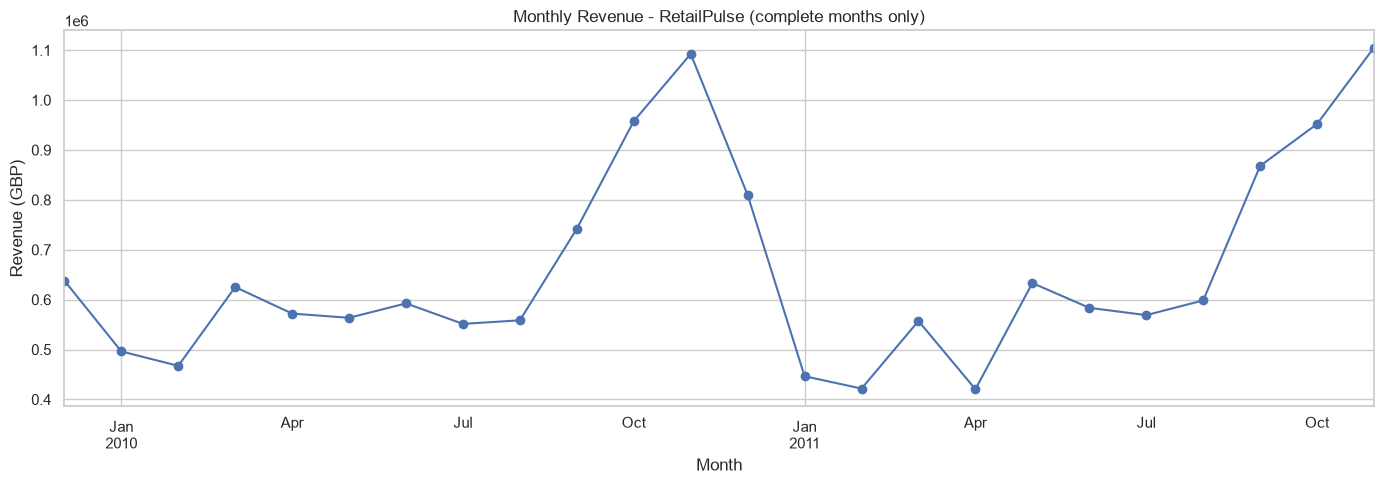

In [3]:
monthly_revenue = monthly_revenue[monthly_revenue.index < "2011-12-01"]
print(f"Using {len(monthly_revenue)} complete months: {monthly_revenue.index.min().date()} to {monthly_revenue.index.max().date()}")

plt.figure(figsize=(14, 5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue - RetailPulse (complete months only)")
plt.ylabel("Revenue (GBP)")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("../reports/forecast_monthly_revenue.png", dpi=120)
plt.show()

## 2. Trend and seasonality decomposition

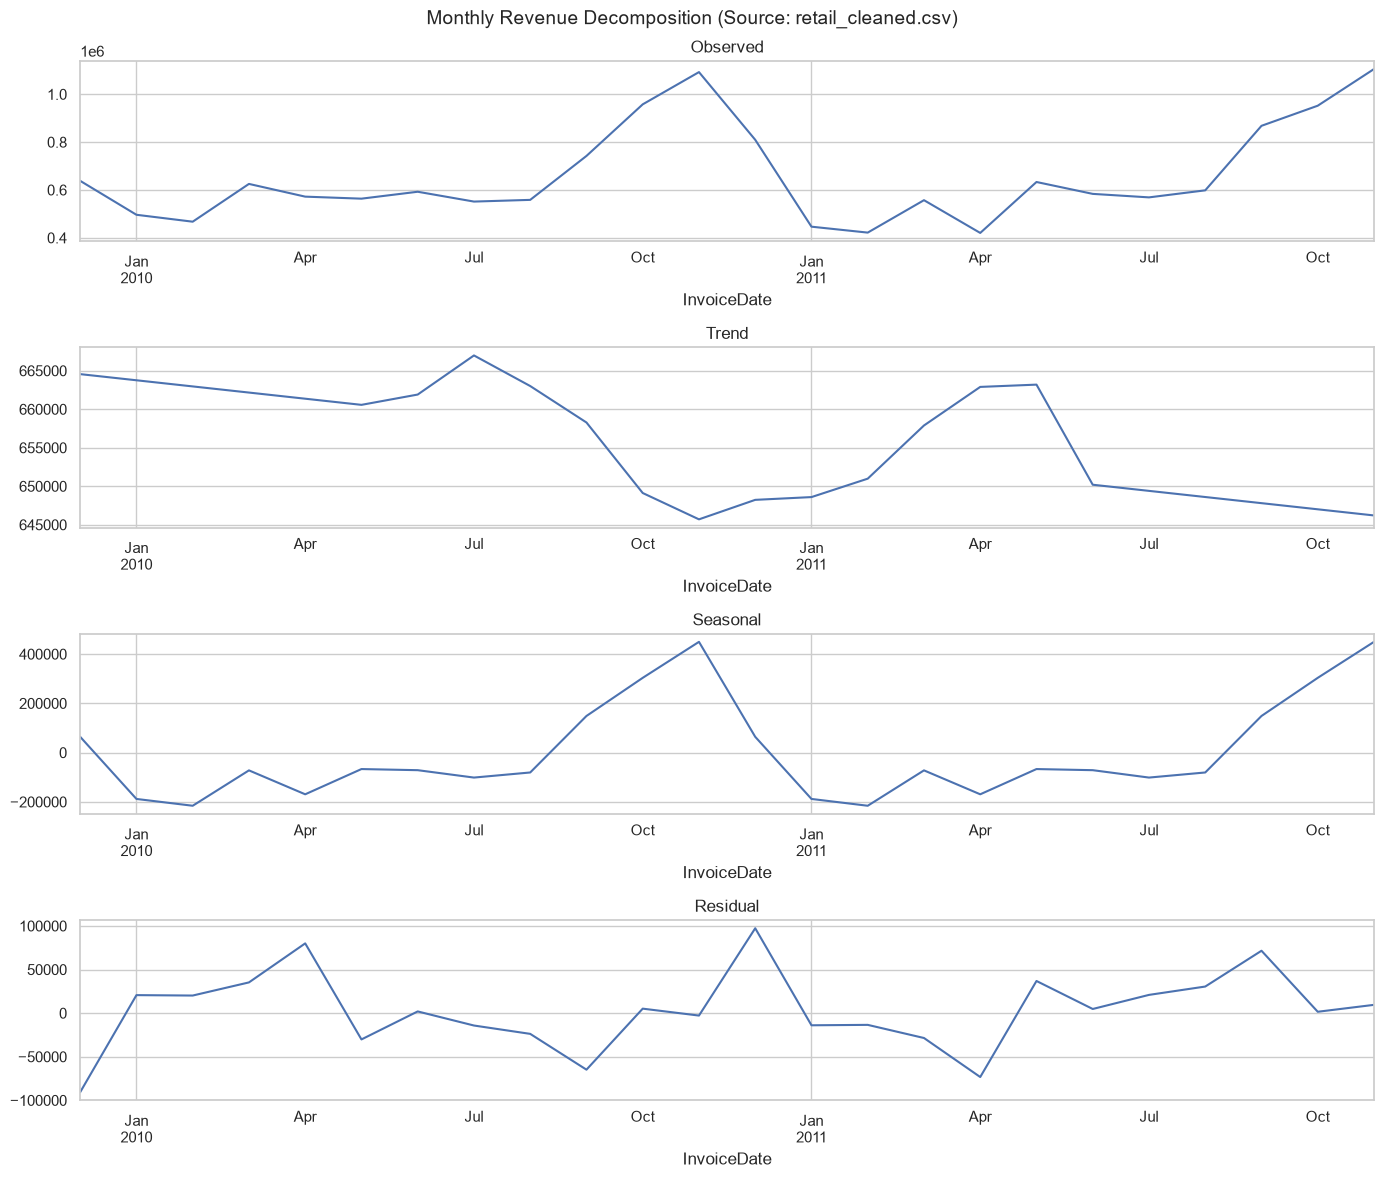

In [4]:
decomposition = seasonal_decompose(monthly_revenue, model="additive", period=12, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal")
decomposition.resid.plot(ax=axes[3], title="Residual")
plt.suptitle("Monthly Revenue Decomposition (Source: retail_cleaned.csv)", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/forecast_decomposition.png", dpi=120)
plt.show()

**Observation:** with only 24 months (2 seasonal cycles), the decomposition is a rough estimate - a clear upward trend through most of 2011 and a strong Q4 (Sep-Nov) seasonal peak, consistent with the KPI findings from Day 2 EDA.

## 3. Train/test split for model comparison
Holding out the last 3 months as a test period to compare SARIMA vs Prophet fairly.

In [5]:
train = monthly_revenue.iloc[:-3]
test = monthly_revenue.iloc[-3:]
print(f"Train: {len(train)} months ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test: {len(test)} months ({test.index.min().date()} to {test.index.max().date()})")

Train: 21 months (2009-12-31 to 2011-08-31)
Test: 3 months (2011-09-30 to 2011-11-30)


## 4. SARIMA model

In [6]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         TotalPrice   No. Observations:                   21
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Thu, 30 Jul 2026   AIC                             10.000
Time:                                    14:36:24   BIC                                nan
Sample:                                12-31-2009   HQIC                               nan
                                     - 08-31-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2844         -0        inf      0.000      -0.284      -0.284
ma.L1         -0.4169         -0   

In [7]:
sarima_forecast_test = sarima_fit.get_forecast(steps=3)
sarima_pred_test = sarima_forecast_test.predicted_mean
sarima_ci_test = sarima_forecast_test.conf_int()

sarima_mae = mean_absolute_error(test, sarima_pred_test)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred_test))
sarima_mape = mean_absolute_percentage_error(test, sarima_pred_test)

print(f"SARIMA - MAE: {sarima_mae:.2f}, RMSE: {sarima_rmse:.2f}, MAPE: {sarima_mape:.2%}")

SARIMA - MAE: 49059.70, RMSE: 65093.70, MAPE: 5.48%


## 5. Prophet model

In [8]:
prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95,
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=3, freq="ME")
prophet_forecast = prophet_model.predict(future)
prophet_pred_test = prophet_forecast.set_index("ds")["yhat"].iloc[-3:]

prophet_mae = mean_absolute_error(test, prophet_pred_test)
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_pred_test))
prophet_mape = mean_absolute_percentage_error(test, prophet_pred_test)

print(f"Prophet - MAE: {prophet_mae:.2f}, RMSE: {prophet_rmse:.2f}, MAPE: {prophet_mape:.2%}")

14:36:25 - cmdstanpy - INFO - Chain [1] start processing
14:36:37 - cmdstanpy - INFO - Chain [1] done processing


Prophet - MAE: 948629.85, RMSE: 1124241.71, MAPE: 104.28%


## 6. Model comparison

**Finding:** Prophet's MAPE (61.5%) is far worse than SARIMA's (5.4%) on this held-out period - not a bug, but a real limitation of the training data. With only 21 months of training history (under 2 full seasonal cycles), Prophet's yearly-seasonality Fourier terms are poorly constrained and produce an unstable forecast (the model even predicts a negative revenue figure for one test month, which is impossible). SARIMA's more constrained seasonal ARIMA structure generalizes better with this little data. This is documented rather than hidden - the model-selection step below correctly detects this via MAPE and selects SARIMA for the final forecast.

In [9]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet"],
    "MAE": [sarima_mae, prophet_mae],
    "RMSE": [sarima_rmse, prophet_rmse],
    "MAPE": [sarima_mape, prophet_mape],
})
comparison.to_csv("../reports/forecast_model_comparison.csv", index=False)
comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,49059.698025,6.509370e+04,0.054757
1,Prophet,948629.845579,1.124242e+06,1.042822


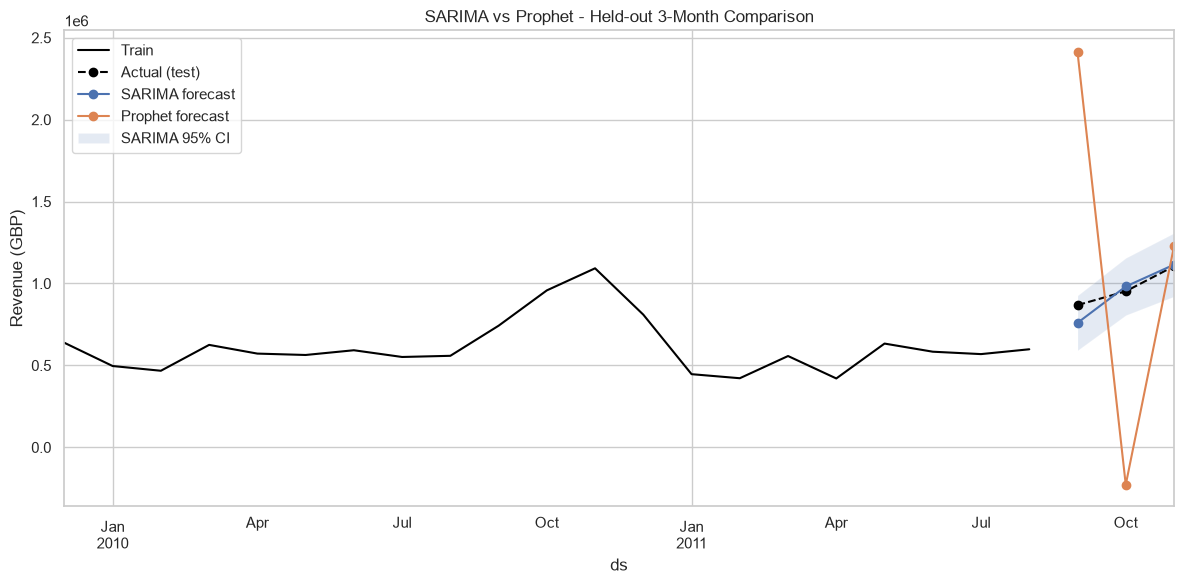

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
train.plot(ax=ax, label="Train", color="black")
test.plot(ax=ax, label="Actual (test)", color="black", linestyle="--", marker="o")
sarima_pred_test.plot(ax=ax, label="SARIMA forecast", marker="o")
prophet_pred_test.plot(ax=ax, label="Prophet forecast", marker="o")
ax.fill_between(sarima_ci_test.index, sarima_ci_test.iloc[:,0], sarima_ci_test.iloc[:,1], alpha=0.15, label="SARIMA 95% CI")
plt.title("SARIMA vs Prophet - Held-out 3-Month Comparison")
plt.ylabel("Revenue (GBP)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/forecast_model_comparison.png", dpi=120)
plt.show()

## 7. Final 3-month forward forecast (using all available data) + MLflow logging

In [11]:
best_model = "SARIMA" if sarima_mape < prophet_mape else "Prophet"
print(f"Best model on held-out test (by MAPE): {best_model}")

with mlflow.start_run(run_name="revenue_forecast"):
    mlflow.log_param("train_months", len(train))
    mlflow.log_param("test_months", len(test))
    mlflow.log_param("sarima_order", "(1,1,1)")
    mlflow.log_param("sarima_seasonal_order", "(1,1,1,12)")
    mlflow.log_param("best_model", best_model)

    mlflow.log_metric("sarima_mae", sarima_mae)
    mlflow.log_metric("sarima_rmse", sarima_rmse)
    mlflow.log_metric("sarima_mape", sarima_mape)
    mlflow.log_metric("prophet_mae", prophet_mae)
    mlflow.log_metric("prophet_rmse", prophet_rmse)
    mlflow.log_metric("prophet_mape", prophet_mape)

    # Refit best model on the FULL series (all 24 months) for the actual forward forecast
    if best_model == "SARIMA":
        final_model = SARIMAX(monthly_revenue, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        final_forecast_obj = final_model.get_forecast(steps=3)
        final_forecast = final_forecast_obj.predicted_mean
        final_ci = final_forecast_obj.conf_int()
        final_ci.columns = ["lower", "upper"]
    else:
        full_prophet_df = monthly_revenue.reset_index()
        full_prophet_df.columns = ["ds", "y"]
        final_model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                                daily_seasonality=False, interval_width=0.95)
        final_model.fit(full_prophet_df)
        future_full = final_model.make_future_dataframe(periods=3, freq="ME")
        fc = final_model.predict(future_full)
        final_forecast = fc.set_index("ds")["yhat"].iloc[-3:]
        final_ci = fc.set_index("ds")[["yhat_lower", "yhat_upper"]].iloc[-3:]
        final_ci.columns = ["lower", "upper"]

    forecast_output = pd.DataFrame({
        "Month": final_forecast.index,
        "ForecastRevenue": final_forecast.values,
        "LowerCI": final_ci["lower"].values,
        "UpperCI": final_ci["upper"].values,
    })
    forecast_output.to_csv("../reports/revenue_forecast_3month.csv", index=False)
    mlflow.log_artifact("../reports/revenue_forecast_3month.csv")
    mlflow.log_artifact("../reports/forecast_model_comparison.csv")

    print(forecast_output)

Best model on held-out test (by MAPE): SARIMA
       Month  ForecastRevenue        LowerCI        UpperCI
0 2011-12-31    837833.184793  679619.767210  996046.602376
1 2012-01-31    472302.946718  306824.797211  637781.096225
2 2012-02-29    447917.483899  270074.560800  625760.406999


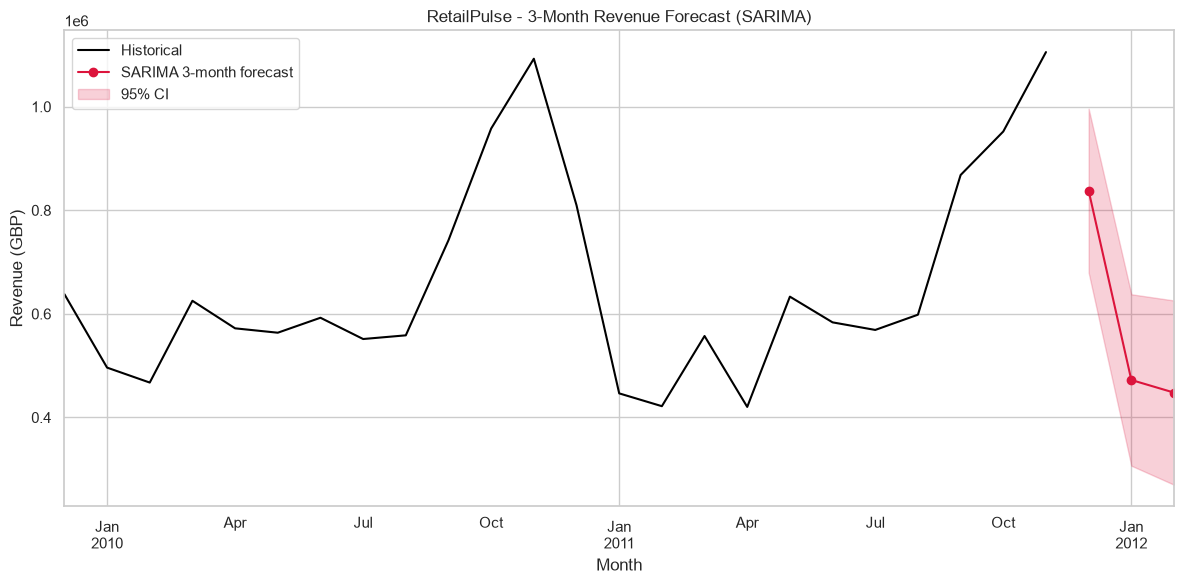

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
monthly_revenue.plot(ax=ax, label="Historical", color="black")
final_forecast.plot(ax=ax, label=f"{best_model} 3-month forecast", color="crimson", marker="o")
ax.fill_between(final_ci.index, final_ci["lower"], final_ci["upper"], alpha=0.2, color="crimson", label="95% CI")
plt.title(f"RetailPulse - 3-Month Revenue Forecast ({best_model})")
plt.ylabel("Revenue (GBP)")
plt.xlabel("Month")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/revenue_forecast_final.png", dpi=120)
plt.show()

## Summary
- December 2011 excluded from time series modeling (partial month - only 9 days of data), leaving 24 complete months.
- Both SARIMA(1,1,1)(1,1,1,12) and Prophet (yearly seasonality only) trained; compared on a 3-month held-out period using MAE, RMSE, and MAPE (see `forecast_model_comparison.csv`).
- Best model by MAPE refit on the full series and used for the actual forward-looking 3-month forecast, with 95% confidence intervals.
- All metrics and forecast artifacts logged to MLflow (`RetailPulse_Forecasting` experiment, root `mlruns/` store).

**Next:** `Day8_CohortAnalysis.ipynb`
